In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('data/processed', exist_ok=True)
os.makedirs('reports/figures', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

df = pd.read_parquet('data/processed/online_retail_clean.parquet')

print(f'Loaded {len(df):,} transactions | {df["Customer ID"].nunique():,} customers')
print(f'Date range: {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')

Loaded 392,693 transactions | 4,338 customers
Date range: 2010-12-01 → 2011-12-09


In [3]:
# One day after the last recorded transaction — the standard RFM convention
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(f'Snapshot date : {snapshot_date.date()}')
print(f'Last transaction: {df["InvoiceDate"].max().date()}')

Snapshot date : 2011-12-10
Last transaction: 2011-12-09


In [4]:
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice',     'nunique'),
    Monetary  = ('Revenue',     'sum')
).reset_index()

print(f'RFM table shape: {rfm.shape}')
print()
print(rfm.describe().round(2))

RFM table shape: (4338, 4)

       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2048.69
std     100.01       7.70    8985.23
min       1.00       1.00       3.75
25%      18.00       1.00     306.48
50%      51.00       2.00     668.57
75%     142.00       5.00    1660.60
max     374.00     209.00  280206.02


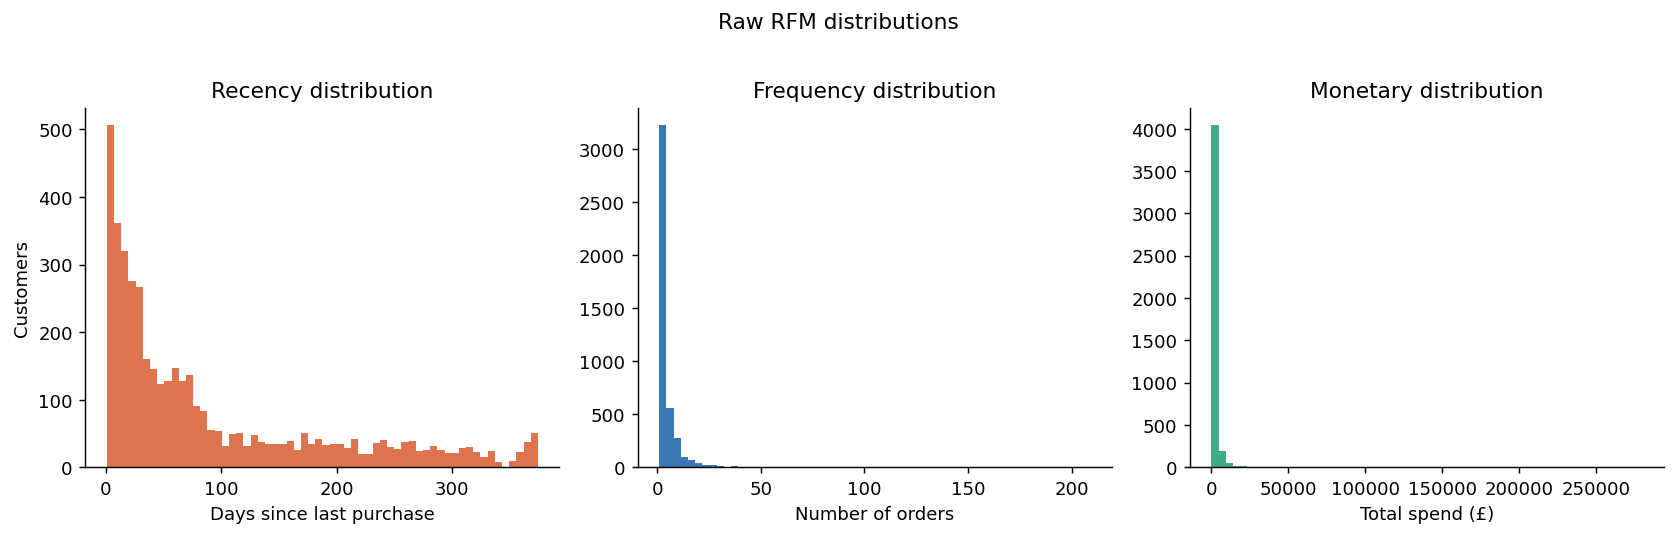


Skewness:
  Recency      1.25
  Frequency    12.07
  Monetary     19.34


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].hist(rfm['Recency'],   bins=60, color='#D85A30', alpha=0.85)
axes[0].set_title('Recency distribution')
axes[0].set_xlabel('Days since last purchase')
axes[0].set_ylabel('Customers')

axes[1].hist(rfm['Frequency'],  bins=60, color='#185FA5', alpha=0.85)
axes[1].set_title('Frequency distribution')
axes[1].set_xlabel('Number of orders')

axes[2].hist(rfm['Monetary'],   bins=60, color='#1D9E75', alpha=0.85)
axes[2].set_title('Monetary distribution')
axes[2].set_xlabel('Total spend (£)')

plt.suptitle('Raw RFM distributions', y=1.02)
plt.tight_layout()
plt.savefig('reports/figures/02_rfm_distributions_raw.png', bbox_inches='tight')
plt.show()

# What you'll see:
# Recency   → relatively spread out, slight right skew
# Frequency → heavy right skew — most customers ordered 1–5 times
# Monetary  → extreme right skew — a small number of big spenders
print('\nSkewness:')
for col in ['Recency', 'Frequency', 'Monetary']:
    print(f'  {col:<12} {rfm[col].skew():.2f}')

In [6]:
# Recency: lower days = higher score (reverse labels)
rfm['R_Score'] = pd.qcut(rfm['Recency'],
                          q=5,
                          labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency: higher orders = higher score
# rank(method='first') breaks ties to prevent qcut from failing
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          q=5,
                          labels=[1, 2, 3, 4, 5]).astype(int)

# Monetary: higher spend = higher score
rfm['M_Score'] = pd.qcut(rfm['Monetary'],
                          q=5,
                          labels=[1, 2, 3, 4, 5]).astype(int)

# Confirm each score has roughly equal distribution (~20% each)
for score in ['R_Score', 'F_Score', 'M_Score']:
    print(f'\n{score} distribution:')
    print(rfm[score].value_counts().sort_index())


R_Score distribution:
R_Score
1    865
2    843
3    858
4    904
5    868
Name: count, dtype: int64

F_Score distribution:
F_Score
1    868
2    867
3    868
4    867
5    868
Name: count, dtype: int64

M_Score distribution:
M_Score
1    868
2    867
3    868
4    867
5    868
Name: count, dtype: int64


In [7]:
# Segment string — concatenate score digits for lookup table approach
rfm['RFM_Segment'] = (rfm['R_Score'].astype(str) +
                       rfm['F_Score'].astype(str) +
                       rfm['M_Score'].astype(str))

# Numeric composite — simple sum, range 3–15
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print(f'RFM Score range: {rfm["RFM_Score"].min()} → {rfm["RFM_Score"].max()}')
print(f'\nTop 10 customers by RFM Score:')
print(rfm.nlargest(10, 'RFM_Score')[
    ['Customer ID', 'Recency', 'Frequency', 'Monetary',
     'R_Score', 'F_Score', 'M_Score', 'RFM_Score']
].to_string(index=False))

RFM Score range: 3 → 15

Top 10 customers by RFM Score:
Customer ID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  RFM_Score
      12347        2          7   4310.00        5        5        5         15
      12362        3         10   5226.23        5        5        5         15
      12417        3          9   3649.10        5        5        5         15
      12433        1          7  13375.87        5        5        5         15
      12437        2         18   4951.41        5        5        5         15
      12471        2         30  19788.65        5        5        5         15
      12490        5         10   5417.93        5        5        5         15
      12524        9          8   4485.72        5        5        5         15
      12553        8         10   3692.28        5        5        5         15
      12562        8          7   3781.74        5        5        5         15


In [8]:
def assign_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']

    # Champions: bought recently, buy often, spend the most
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

    # Loyal customers: frequent buyers, not necessarily big spenders
    elif f >= 4 and r >= 3:
        return 'Loyal customers'

    # Potential loyalists: recent customers with some frequency
    elif r >= 4 and f >= 2:
        return 'Potential loyalists'

    # New customers: bought very recently, only once or twice
    elif r == 5 and f == 1:
        return 'New customers'

    # At risk: used to buy often and spend big, haven't returned
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At risk'

    # Can't lose them: big spenders who are going very cold
    elif r == 1 and m >= 4:
        return "Can't lose them"

    # Hibernating: low on all dimensions
    elif r <= 2 and f <= 2:
        return 'Hibernating'

    # Everyone else
    else:
        return 'Needs attention'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print('Segment distribution:')
print(rfm['Segment'].value_counts())

Segment distribution:
Segment
Hibernating            1030
Champions               957
Needs attention         826
Loyal customers         503
Potential loyalists     492
At risk                 453
New customers            42
Can't lose them          35
Name: count, dtype: int64


In [9]:
segment_summary = rfm.groupby('Segment').agg(
    Customers  = ('Customer ID', 'count'),
    Avg_Recency    = ('Recency',   'mean'),
    Avg_Frequency  = ('Frequency', 'mean'),
    Avg_Monetary   = ('Monetary',  'mean'),
    Total_Revenue  = ('Monetary',  'sum'),
).round(1)

segment_summary['Revenue_%'] = (
    segment_summary['Total_Revenue'] /
    segment_summary['Total_Revenue'].sum() * 100
).round(1)

segment_summary = segment_summary.sort_values('Total_Revenue', ascending=False)
print(segment_summary.to_string())

                     Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  Revenue_%
Segment                                                                                           
Champions                  957         12.8           11.1        6051.9      5791640.7       65.2
Loyal customers            503         38.0            5.1        1780.7       895669.6       10.1
At risk                    453        141.6            3.8        1632.4       739477.6        8.3
Potential loyalists        492         17.1            2.0        1030.1       506813.6        5.7
Needs attention            826         78.8            1.7         507.4       419132.3        4.7
Hibernating               1030        216.1            1.1         365.1       376014.4        4.2
Can't lose them             35        270.7            1.3        4065.9       142307.7        1.6
New customers               42          6.9            1.0         385.0        16170.9        0.2


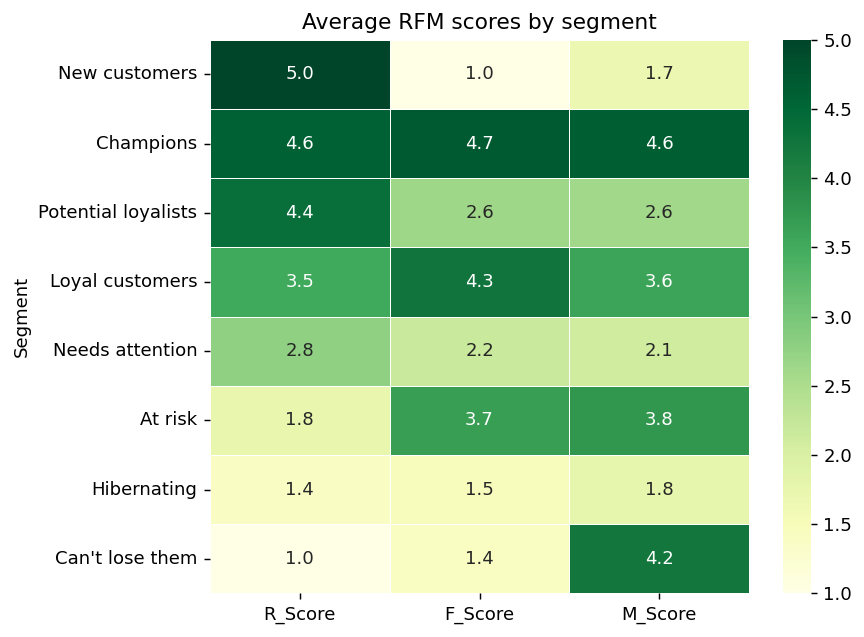

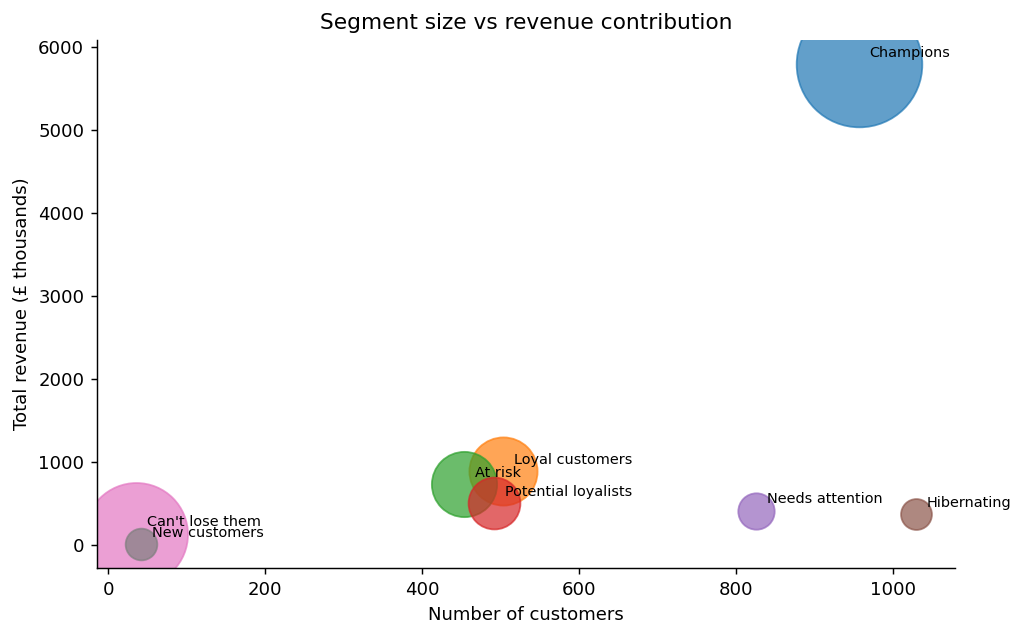

In [10]:
# Heatmap of average RFM scores per segment
heatmap_data = rfm.groupby('Segment')[['R_Score','F_Score','M_Score']].mean().round(2)
heatmap_data = heatmap_data.sort_values('R_Score', ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1f',
    cmap='YlGn',
    linewidths=0.5,
    ax=ax,
    vmin=1, vmax=5
)
ax.set_title('Average RFM scores by segment')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('reports/figures/02_rfm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Segment size vs revenue bubble chart — the 80/20 visual
fig, ax = plt.subplots(figsize=(8, 5))
for seg, row in segment_summary.iterrows():
    ax.scatter(row['Customers'], row['Total_Revenue'] / 1000,
               s=row['Avg_Monetary'] * 0.8,
               alpha=0.7, label=seg)
    ax.annotate(seg,
                xy=(row['Customers'], row['Total_Revenue'] / 1000),
                xytext=(6, 4), textcoords='offset points',
                fontsize=8)

ax.set_xlabel('Number of customers')
ax.set_ylabel('Total revenue (£ thousands)')
ax.set_title('Segment size vs revenue contribution')
plt.tight_layout()
plt.savefig('reports/figures/02_segment_bubble.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
rfm.to_parquet('data/processed/rfm_scored.parquet', index=False)

print('Saved → data/processed/rfm_scored.parquet')
print(f'\nColumns saved: {rfm.columns.tolist()}')
print(f'Customers    : {len(rfm):,}')
print(f'\nSegment counts:')
print(rfm['Segment'].value_counts().to_string())

Saved → data/processed/rfm_scored.parquet

Columns saved: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Segment', 'RFM_Score', 'Segment']
Customers    : 4,338

Segment counts:
Segment
Hibernating            1030
Champions               957
Needs attention         826
Loyal customers         503
Potential loyalists     492
At risk                 453
New customers            42
Can't lose them          35
